# LLM Chess Match — Fireworks GLM-5.2 vs Anthropic Opus 4.8

Two AIs play **N games** of chess against each other, swapping who plays White each game so neither model always gets the first-move advantage. The trick: each LLM is told **it** is the assistant in a chess-helper conversation, and the *other* LLM's moves arrive as `user` turns. So from each model's point of view it is the player; the "opponent" is just the user feeding it the opponent's last move.

- **Player A:** Fireworks GLM-5.2 (`accounts/fireworks/models/glm-5p2`) via the OpenAI-compatible endpoint.
- **Player B:** Anthropic Opus 4.8 (`claude-opus-4-8`) via the native Anthropic SDK.

Moves are validated and tracked with `python-chess`; illegal/unparseable replies get one retry with a legal-move hint, then a forfeit. We track:

- **Wins** overall and broken down by whether the model played White or Black.
- **Move latency** per model (mean / median / min / max / total thinking time).
- **Illegal move attempts** — both unparseable replies (model went off-script) and parseable-but-illegal SAN.
- **Forfeits** — games lost because a model exhausted its retries.

Each move streams live to the cell output, so you watch the game as it happens.

**Prereqs:** `FIREWORKS_API_KEY` and `ANTHROPIC_API_KEY` in `training/.env` or your shell.

## 1. Setup

In [1]:
# Run once if imports fail.
import sys
!{sys.executable} -m pip install -q anthropic openai python-chess python-dotenv

In [2]:
# --- edit these ---
# The two players. Each is (provider_key, display_name).
PLAYER_A = ("fireworks", "Kimi-K3 (Fireworks)")
PLAYER_B = ("anthropic", "Opus 4.8 (Anthropic)")

FIREWORKS_MODEL = "accounts/fireworks/models/kimi-k3"
ANTHROPIC_MODEL = "claude-opus-4-8"                    # native Anthropic model id (no provider prefix)
OPENAI_MODEL = None


N_GAMES = 4             # even number so each model gets White exactly half the time
assert N_GAMES % 2 == 0

MAX_MOVES = 120         # hard cap on plies per game (avoid runaway games)
MAX_TOKENS = 1024       # moves should be short; keep this small
MAX_RETRIES_PER_MOVE = 1  # retries with a legality hint before forfeit

# Incremental save: each completed game is appended here as one JSONL line and
# fsynced, so a crash mid-match keeps all finished games. Set to None to disable.
# If RESUME is True and the file exists, already-saved games are loaded and the
# match continues from where it left off (skipping completed game indices).
SAVE_PATH = "llm_chess_games.jsonl"
RESUME = False

# Game to inspect in detail in the final cell (0-indexed).
INSPECT_GAME = 0

In [3]:
import json
import os
import re
import time
from pathlib import Path

from dotenv import load_dotenv

training_dir = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "training" and (p / "pyproject.toml").exists()),
    Path("../../").resolve(),
)
load_dotenv(training_dir / ".env")

missing = [k for k in ("FIREWORKS_API_KEY", "ANTHROPIC_API_KEY") if not os.getenv(k)]
if missing:
    raise EnvironmentError(f"Missing {missing}. Set them in {training_dir / '.env'} or your shell.")

import chess
from anthropic import AsyncAnthropic
from openai import AsyncOpenAI

fireworks_client = AsyncOpenAI(
    base_url="https://api.fireworks.ai/inference/v1",
    api_key=os.environ["FIREWORKS_API_KEY"],
)
anthropic_client = AsyncAnthropic()  # reads ANTHROPIC_API_KEY

openai_client = AsyncOpenAI(
    base_url="https://api.openai.com/v1",
    api_key=os.environ["OPENAI_API_KEY"],
)
print("Clients ready.")

Clients ready.


## 2. Prompts

Each color gets a system prompt framing the model as the player for that color; the conversation alternates roles. The model's own moves come back as the assistant turn, and the opponent's moves arrive as user turns. We keep each side's message history independent (a model only ever sees moves from its own vantage point).

We let the model **think first** — analyze the position, weigh candidate moves, etc. — but require the final move in a **box** like `[e4]` or `[Nf3]`. A regex pulls the last bracketed token out of the reply and `python-chess` parses it as SAN against the current board, so any legal SAN works. The system prompt is keyed on **color**, not model identity — whichever model is assigned White gets `WHITE_SYS`. Boxing the move (instead of asking for move-only output) keeps the model's reasoning in-context for later turns and cuts down on illegal/unparseable replies.

In [4]:
WHITE_SYS = (
    "You are a world-class chess engine playing as White. "
    "You will be told the opponent's last move (or 'starts the game' on the first turn). "
    "Analyze the position briefly, consider candidate moves, and choose White's best reply. "
    "After your reasoning, state your final move on its own line inside square brackets, e.g. [e4], "
    "[Nf3], [Bb5], [O-O], [Qxd5#]. The move must be in standard algebraic notation and legal in the "
    "current position. Only the bracketed move is read by the harness, so always end with exactly one."
)

BLACK_SYS = (
    "You are a world-class chess engine playing as Black. "
    "You will be told the opponent's last move. "
    "Analyze the position briefly, consider candidate moves, and choose Black's best reply. "
    "After your reasoning, state your final move on its own line inside square brackets, e.g. [e5], "
    "[Nc6], [Bc5], [O-O-O], [Qxf7#]. The move must be in standard algebraic notation and legal in the "
    "current position. Only the bracketed move is read by the harness, so always end with exactly one."
)

## 3. Move generation + parsing

`generate_move(provider, sys_prompt, history, hint)` dispatches to the right SDK and returns `(raw_text, parsed_san, latency_seconds)`. The two providers differ: Fireworks takes `system` in the messages array and accepts `temperature`; Anthropic takes `system` as a top-level arg and (on Opus 4.8) rejects `temperature`.

In [5]:
# A bracketed move looks like [e4], [Nf3], [O-O], [Qxd5#]. We take the LAST one,
# since the model may mention candidate moves in brackets during analysis before
# committing. Fall back to a bare SAN match if the model forgets the brackets.
_SAN_INNER = r"O-O-O|O-O|[KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](?:=[QRBN])?[+#]?"
_BOX_RE = re.compile(r"\[\s*(" + _SAN_INNER + r")\s*\]")
_SAN_RE = re.compile(r"\b(" + _SAN_INNER + r")\b")


def extract_san(text: str) -> str | None:
    if not text:
        return None
    boxes = _BOX_RE.findall(text)
    if boxes:
        return boxes[-1].strip()
    # No box — try a bare SAN token as a fallback.
    m = _SAN_RE.search(text.strip().strip("`\"'"))
    return m.group(1) if m else None


async def generate_move(provider: str, sys_prompt: str, history: list[dict], hint: str | None) -> tuple[str, str | None, float]:
    """Return (raw_text, parsed_san, latency_s). provider is 'fireworks' or 'anthropic'."""
    t0 = time.perf_counter()
    if provider == "fireworks":
        msgs = [{"role": "system", "content": sys_prompt}, *history]
        if hint:
            msgs.append({"role": "user", "content": hint})
        resp = await fireworks_client.chat.completions.create(
            model=FIREWORKS_MODEL,
            max_tokens=MAX_TOKENS,
            messages=msgs,
            reasoning_effort="high",  # GLM-5.2 'high' is the lower of its two real tiers (high/max)
        )
        raw = resp.choices[0].message.content or ""
    elif provider == "anthropic":
        msgs = [*history]
        if hint:
            msgs.append({"role": "user", "content": hint})
        resp = await anthropic_client.messages.create(
            model=ANTHROPIC_MODEL,
            max_tokens=MAX_TOKENS,
            system=sys_prompt,
            messages=msgs,
            thinking={"type": "adaptive"},  # Opus 4.8: adaptive thinking; effort controls depth
            output_config={"effort": "high"},  # 'high' is Opus 4.8's default tier
        )
        raw = "".join(b.text for b in resp.content if b.type == "text")
    elif provider == "openai":
        msgs = [*history]
        if hint:
            msgs.append({"role": "user", "content": hint})
        resp = await openai_client.chat.completions.create(
            model=OPENAI_MODEL,
            reasoning_effort="high",
            messages=msgs
        )
        raw = resp.choices[0].message.content or ""
    
    dt = time.perf_counter() - t0
    return raw, extract_san(raw), dt

## 4. Game loop

`play_game` plays one game with a given White/Black assignment and returns a result dict tracking outcome, latencies, illegal attempts, and forfeits. `run_match` plays `N_GAMES`, swapping colors each game so each model plays White half the time.

In [6]:
async def play_game(game_idx: int, white: tuple[str, str], black: tuple[str, str]) -> dict:
    white_prov, white_name = white
    black_prov, black_name = black
    board = chess.Board()
    white_hist: list[dict] = []
    black_hist: list[dict] = []
    log: list[dict] = []
    latencies = {white_prov: [], black_prov: []}
    unparseable = {white_prov: 0, black_prov: 0}   # no SAN found in reply
    illegal_san = {white_prov: 0, black_prov: 0}    # SAN found but not legal
    forfeit_prov: str | None = None

    def color_info(side: str):
        if side == "white":
            return white_prov, white_name, WHITE_SYS
        return black_prov, black_name, BLACK_SYS

    async def take_turn(side: str) -> bool:
        prov, name, sys_prompt = color_info(side)
        history = white_hist if side == "white" else black_hist
        is_first = (len(log) == 0 and side == "white")
        opp_san = log[-1]["san"] if log else None
        user_msg = ("White starts the game. Make White's first move." if is_first
                    else f"Opponent played: {opp_san}. Make your move.")
        history.append({"role": "user", "content": user_msg})
        ply_label = f"{len(log)//2 + 1}." + (" " if side == "white" else "..")
        raw = ""
        first_attempt_failed = False  # binary: did this move require any retry?
        # Move number within this model's color (1 = its first move, 2 = its second, ...).
        move_number = sum(1 for e in log if e["side"] == side) + 1
        for attempt in range(MAX_RETRIES_PER_MOVE + 1):
            hint = None
            if attempt > 0:
                legal = ", ".join(board.san(m) for m in board.legal_moves)
                hint = (f"Your previous reply did not contain a legal move. "
                        f"Pick one of these legal SAN moves and put it in square brackets, "
                        f"e.g. [Nf3]. Legal moves: {legal}.")
                print(f"  [{name}] retry {attempt} (asking for legal SAN)...", flush=True)
            else:
                print(f"{ply_label} {name} thinking...", end=" ", flush=True)
            raw, san, dt = await generate_move(prov, sys_prompt, history, hint)
            latencies[prov].append(dt)
            if san is None:
                unparseable[prov] += 1
                first_attempt_failed = True
                print(f"no SAN parsed ({dt:.1f}s): {raw[:50]!r}", flush=True)
                history.append({"role": "assistant", "content": raw})
                continue
            try:
                move = board.parse_san(san)
            except (chess.IllegalMoveError, chess.InvalidMoveError, chess.AmbiguousMoveError):
                illegal_san[prov] += 1
                first_attempt_failed = True
                print(f"illegal ({dt:.1f}s): {san!r} (raw {raw[:100]!r})", flush=True)
                history.append({"role": "assistant", "content": raw})
                continue
            history.append({"role": "assistant", "content": san})
            board.push(move)
            log.append({"ply": len(log) + 1, "side": side, "san": san, "raw": raw,
                        "latency": dt, "provider": prov,
                        "move_number": move_number, "retried": first_attempt_failed})
            tag = " (retried)" if first_attempt_failed else ""
            print(f"played {san} ({dt:.1f}s){tag}", flush=True)
            return True
        nonlocal forfeit_prov
        forfeit_prov = prov
        log.append({"ply": len(log) + 1, "side": side, "san": None, "raw": raw,
                    "forfeit": True, "provider": prov,
                    "move_number": move_number, "retried": first_attempt_failed})
        return False

    print(f"\n=== Game {game_idx + 1}: {white_name} (White) vs {black_name} (Black) ===", flush=True)
    while not board.is_game_over() and len(log) < MAX_MOVES:
        side = "white" if board.turn == chess.WHITE else "black"
        ok = await take_turn(side)
        if not ok:
            break
    print(flush=True)

    # Determine outcome + winner.
    outcome = "ongoing"
    winner_prov = winner_name = None
    loser_prov = None
    if forfeit_prov is not None:
        outcome = "forfeit"
        loser_prov = forfeit_prov
        winner_prov = black_prov if forfeit_prov == white_prov else white_prov
        winner_name = black_name if forfeit_prov == white_prov else white_name
    elif board.is_checkmate():
        outcome = "checkmate"
        loser_prov = white_prov if board.turn == chess.WHITE else black_prov
        winner_prov = black_prov if board.turn == chess.WHITE else white_prov
        winner_name = black_name if board.turn == chess.WHITE else white_name
    elif board.is_stalemate():
        outcome = "stalemate"
    elif board.is_insufficient_material():
        outcome = "insufficient_material"
    elif board.can_claim_fifty_moves() or board.is_fivefold_repetition():
        outcome = "draw_rule"
    elif len(log) >= MAX_MOVES:
        outcome = "move_cap"

    return {
        "game": game_idx,
        "white": {"provider": white_prov, "name": white_name},
        "black": {"provider": black_prov, "name": black_name},
        "plies": len(log),
        "outcome": outcome,
        "winner_provider": winner_prov,
        "winner_name": winner_name,
        "loser_provider": loser_prov,
        "forfeit_provider": forfeit_prov,
        "latencies": latencies,
        "unparseable": unparseable,
        "illegal_san": illegal_san,
        "log": log,
        "board_fen": board.fen(),
    }


async def run_match() -> list[dict]:
    players = [PLAYER_A, PLAYER_B]
    games: list[dict] = []

    # Resume from a prior partial run if asked and a save exists.
    loaded_indices: set[int] = set()
    if RESUME and SAVE_PATH and os.path.exists(SAVE_PATH):
        with open(SAVE_PATH, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    g = json.loads(line)
                    games.append(g)
                    loaded_indices.add(g["game"])
        print(f"Resumed {len(games)} game(s) from {SAVE_PATH}: "
              f"indices {sorted(loaded_indices)}", flush=True)

    # Open the save file in append mode for the whole match; each game is one
    # JSONL line, flushed + fsynced so it's durable if the kernel dies mid-run.
    save_fh = open(SAVE_PATH, "a") if SAVE_PATH else None

    try:
        for i in range(N_GAMES):
            if i in loaded_indices:
                continue  # already have this game from the resume file
            # Swap colors each game so each model plays White half the time.
            white, black = players[i % 2], players[(i + 1) % 2]
            g = await play_game(i, white, black)
            games.append(g)
            if save_fh is not None:
                save_fh.write(json.dumps(g) + "\n")
                save_fh.flush()
                os.fsync(save_fh.fileno())
                print(f"  [saved game {i} to {SAVE_PATH}]", flush=True)
    finally:
        if save_fh is not None:
            save_fh.close()
    return games

games = await run_match()
print(f"\nMatch complete: {len(games)} games played.")


=== Game 1: Kimi-K3 (Fireworks) (White) vs Opus 4.8 (Anthropic) (Black) ===
1.  Kimi-K3 (Fireworks) thinking... played e4 (625.4s)
1... Opus 4.8 (Anthropic) thinking... played c5 (605.0s)
2.  Kimi-K3 (Fireworks) thinking... 

APITimeoutError: Request timed out.

### Recover from a partial run

If the kernel died mid-match, the `games` variable is gone but finished games are safe in `SAVE_PATH`. Run this cell to reload them so the stats/chart cells below work without re-playing the match. (Also handy for re-computing stats on an old run.)

In [ ]:
# Load every finished game from the JSONL save (overwrites the in-memory `games`).
if SAVE_PATH and os.path.exists(SAVE_PATH):
    loaded = []
    with open(SAVE_PATH, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                loaded.append(json.loads(line))
        loaded.sort(key=lambda g: g["game"])
    print(f"Loaded {len(loaded)} game(s) from {SAVE_PATH} (indices "
          f"{[g['game'] for g in loaded]}). Setting `games = loaded`.")
    games = loaded
else:
    print(f"No save file at {SAVE_PATH!r}; keeping in-memory `games` ({len(games)} game(s)).")

Loaded 20 game(s) from llm_chess_games.jsonl (indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]). Setting `games = loaded`.


## 5. Per-game results

In [ ]:
for g in games:
    winner = g["winner_name"] or "— (draw)"
    print(
        f"Game {g['game'] + 1}: "
        f"{g['white']['name']} (W) vs {g['black']['name']} (B) | "
        f"{g['plies']} plies | {g['outcome']} | winner: {winner}"
    )

Game 1: GLM-5.2 (Fireworks) (W) vs Opus 4.8 (Anthropic) (B) | 28 plies | forfeit | winner: GLM-5.2 (Fireworks)
Game 2: Opus 4.8 (Anthropic) (W) vs GLM-5.2 (Fireworks) (B) | 26 plies | forfeit | winner: Opus 4.8 (Anthropic)
Game 3: GLM-5.2 (Fireworks) (W) vs Opus 4.8 (Anthropic) (B) | 30 plies | forfeit | winner: GLM-5.2 (Fireworks)
Game 4: Opus 4.8 (Anthropic) (W) vs GLM-5.2 (Fireworks) (B) | 22 plies | forfeit | winner: Opus 4.8 (Anthropic)
Game 5: GLM-5.2 (Fireworks) (W) vs Opus 4.8 (Anthropic) (B) | 26 plies | forfeit | winner: GLM-5.2 (Fireworks)
Game 6: Opus 4.8 (Anthropic) (W) vs GLM-5.2 (Fireworks) (B) | 19 plies | forfeit | winner: GLM-5.2 (Fireworks)
Game 7: GLM-5.2 (Fireworks) (W) vs Opus 4.8 (Anthropic) (B) | 27 plies | forfeit | winner: Opus 4.8 (Anthropic)
Game 8: Opus 4.8 (Anthropic) (W) vs GLM-5.2 (Fireworks) (B) | 31 plies | forfeit | winner: GLM-5.2 (Fireworks)
Game 9: GLM-5.2 (Fireworks) (W) vs Opus 4.8 (Anthropic) (B) | 15 plies | forfeit | winner: Opus 4.8 (Anthropi

## 6. Aggregate stats

Wins overall + broken down by who went first (White vs Black), forfeits, illegal-move attempts, and per-model move latency.

Match: Kimi-K3 (Fireworks) vs Opus 4.8 (Anthropic) over 20 games

WINS (overall and by who went first)
Model                     Wins  W as W  W as B  Losses  Draws
Kimi-K3 (Fireworks)         11       6       5       9      -
Opus 4.8 (Anthropic)         9       5       4      11      -
(draws)                                                     0

FORFEITS (games lost by exhausting retries on illegal moves)
  Kimi-K3 (Fireworks)      9 forfeit loss(es)
  Opus 4.8 (Anthropic)     11 forfeit loss(es)

ILLEGAL MOVE ATTEMPTS (across all retries, all games)
Model                     Unparseable  Illegal SAN  Total bad
Kimi-K3 (Fireworks)                 4           43         47
Opus 4.8 (Anthropic)               37            0         37
  (unparseable = model went off-script, no SAN found; illegal SAN = move parsed but not legal on the board)

MOVE LATENCY (per model, all thinking time across all games)
  Kimi-K3 (Fireworks)      n=299 | mean 6.30s | median 4.74s | min 0.43s | max 39.8

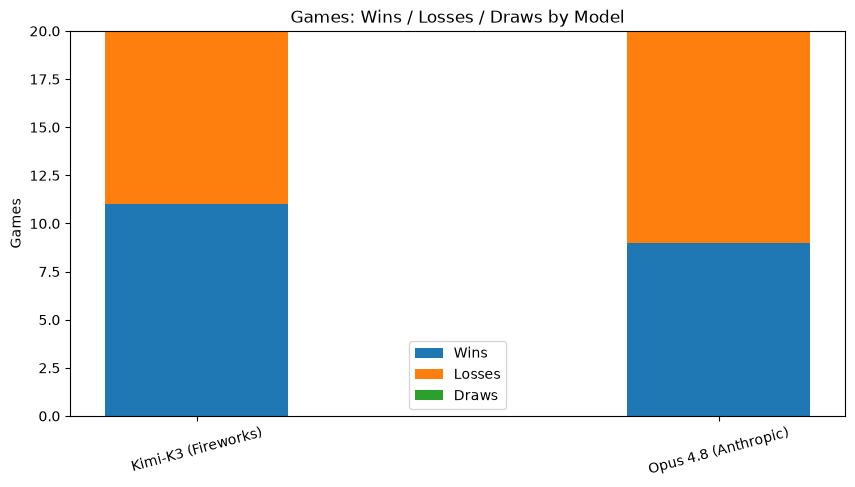

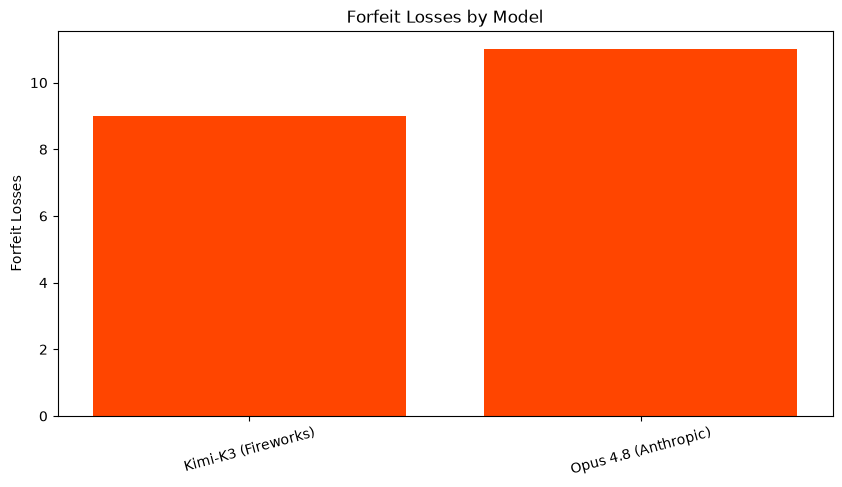

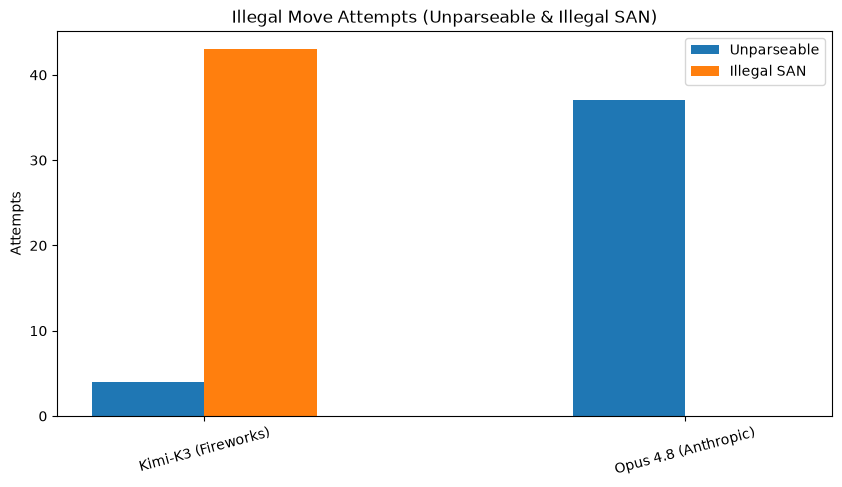

/var/folders/0h/c6c4v8153bz0v35w1mcvqvpw0000gn/T/ipykernel_91751/32746787.py:148: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(latencies, vert=True, patch_artist=True)


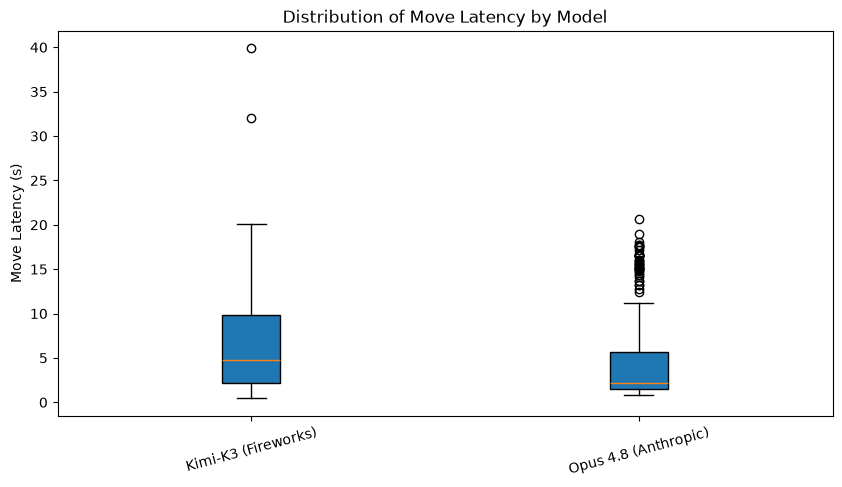

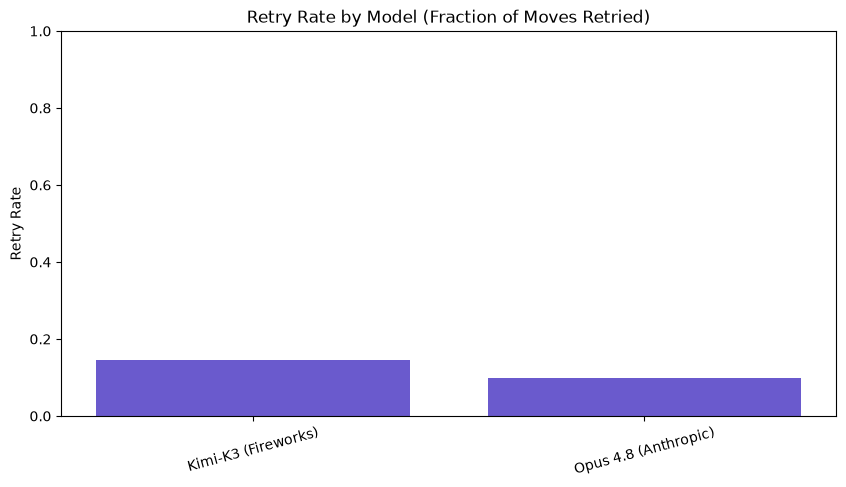

In [ ]:
import statistics
import matplotlib.pyplot as plt
import numpy as np

# Build a per-provider accumulator.
providers = {PLAYER_A[0]: PLAYER_A[1], PLAYER_B[0]: PLAYER_B[1]}
stats = {
    p: {
        "name": n, "wins": 0, "wins_as_white": 0, "wins_as_black": 0,
        "losses": 0, "forfeit_losses": 0,
        "unparseable": 0, "illegal_san": 0, "illegal_total": 0,
        "latencies": [],
        "moves_total": 0, "moves_retried": 0,
    }
    for p, n in providers.items()
}
draws = 0

for g in games:
    for p in providers:
        stats[p]["unparseable"] += g["unparseable"].get(p, 0)
        stats[p]["illegal_san"] += g["illegal_san"].get(p, 0)
        stats[p]["illegal_total"] += g["unparseable"].get(p, 0) + g["illegal_san"].get(p, 0)
        stats[p]["latencies"].extend(g["latencies"].get(p, []))
    # Per-move retry accounting (binary: did the first attempt fail?).
    for e in g["log"]:
        prov = e["provider"]
        stats[prov]["moves_total"] += 1
        if e.get("retried"):
            stats[prov]["moves_retried"] += 1
    wp = g["winner_provider"]
    if wp is None:
        draws += 1
        continue
    stats[wp]["wins"] += 1
    if g["white"]["provider"] == wp:
        stats[wp]["wins_as_white"] += 1
    else:
        stats[wp]["wins_as_black"] += 1
    if g["loser_provider"] is not None:
        stats[g["loser_provider"]]["losses"] += 1
    if g["forfeit_provider"] is not None:
        stats[g["forfeit_provider"]]["forfeit_losses"] += 1

def fmt_lat(lats: list[float]) -> str:
    if not lats:
        return "no moves"
    return (f"n={len(lats)} | mean {statistics.mean(lats):.2f}s | "
            f"median {statistics.median(lats):.2f}s | "
            f"min {min(lats):.2f}s | max {max(lats):.2f}s | "
            f"total {sum(lats):.1f}s")

# --- Text summary (retain for context, now add plots below) ---
print(f"Match: {PLAYER_A[1]} vs {PLAYER_B[1]} over {len(games)} games\n")
print("=" * 70)
print("WINS (overall and by who went first)")
print("=" * 70)
print(f"{'Model':<24} {'Wins':>5} {'W as W':>7} {'W as B':>7} {'Losses':>7} {'Draws':>6}")
for p, s in stats.items():
    print(f"{s['name']:<24} {s['wins']:>5} {s['wins_as_white']:>7} "
          f"{s['wins_as_black']:>7} {s['losses']:>7} {draws if False else '-':>6}")
print(f"{'(draws)':<24} {'':>5} {'':>7} {'':>7} {'':>7} {draws:>6}")
print()
print("=" * 70)
print("FORFEITS (games lost by exhausting retries on illegal moves)")
print("=" * 70)
for p, s in stats.items():
    print(f"  {s['name']:<24} {s['forfeit_losses']} forfeit loss(es)")
print()
print("=" * 70)
print("ILLEGAL MOVE ATTEMPTS (across all retries, all games)")
print("=" * 70)
print(f"{'Model':<24} {'Unparseable':>12} {'Illegal SAN':>12} {'Total bad':>10}")
for p, s in stats.items():
    print(f"{s['name']:<24} {s['unparseable']:>12} {s['illegal_san']:>12} {s['illegal_total']:>10}")
print("  (unparseable = model went off-script, no SAN found; "
      "illegal SAN = move parsed but not legal on the board)")
print()
print("=" * 70)
print("MOVE LATENCY (per model, all thinking time across all games)")
print("=" * 70)
for p, s in stats.items():
    print(f"  {s['name']:<24} {fmt_lat(s['latencies'])}")
print()
print("=" * 70)
print("RETRY RATE BY MOVE NUMBER (binary: did the model's first attempt fail?)")
print("=" * 70)
print(f"{'Model':<24} {'Moves':>6} {'Retried':>8} {'Retry rate':>11}")
for p, s in stats.items():
    n = s['moves_total']
    r = s['moves_retried']
    rate = f"{r/n:.0%}" if n else "-"
    print(f"{s['name']:<24} {n:>6} {r:>8} {rate:>11}")
print("  (a move counts as 'retried' if the first attempt was unparseable or illegal; "
      "multiple retries on the same move still count as 1)")

# --- Graphs Section ---
figsize = (10, 5)
bar_width = 0.35
x_models = [s["name"] for s in stats.values()]

# 1. Win/loss/draw stacked bar
win_vals = [s["wins"] for s in stats.values()]
loss_vals = [s["losses"] for s in stats.values()]
draw_vals = [draws for _ in stats]  # same draw count for each model

x = np.arange(len(x_models))

fig, ax = plt.subplots(figsize=figsize)
bar1 = ax.bar(x, win_vals, bar_width, label='Wins')
bar2 = ax.bar(x, loss_vals, bar_width, bottom=win_vals, label='Losses')
bar3 = ax.bar(x, draw_vals, bar_width, bottom=np.array(win_vals) + np.array(loss_vals), label='Draws')
ax.set_ylabel("Games")
ax.set_title("Games: Wins / Losses / Draws by Model")
ax.set_xticks(x)
ax.set_xticklabels(x_models, rotation=15)
ax.legend()
plt.show()

# 2. Forfeit losses bar
forfeits = [s["forfeit_losses"] for s in stats.values()]
fig, ax = plt.subplots(figsize=figsize)
ax.bar(x, forfeits, color='orangered')
ax.set_ylabel("Forfeit Losses")
ax.set_title("Forfeit Losses by Model")
ax.set_xticks(x)
ax.set_xticklabels(x_models, rotation=15)
plt.show()

# 3. Illegal move attempts (unparseable and illegal SAN)
unparseable = [s["unparseable"] for s in stats.values()]
illegal_san = [s["illegal_san"] for s in stats.values()]
total_bad = [s["illegal_total"] for s in stats.values()]

fig, ax = plt.subplots(figsize=figsize)
bar1 = ax.bar(x - bar_width/3, unparseable, bar_width/1.5, label='Unparseable')
bar2 = ax.bar(x + bar_width/3, illegal_san, bar_width/1.5, label='Illegal SAN')
ax.set_ylabel("Attempts")
ax.set_title("Illegal Move Attempts (Unparseable & Illegal SAN)")
ax.set_xticks(x)
ax.set_xticklabels(x_models, rotation=15)
ax.legend()
plt.show()

# 4. Move latency boxplot
latencies = [s["latencies"] for s in stats.values()]
fig, ax = plt.subplots(figsize=figsize)
bp = ax.boxplot(latencies, vert=True, patch_artist=True)
# Note: matplotlib does not support 'labels' kwarg for Axes.boxplot, use set_xticklabels instead.
ax.set_xticks(np.arange(1, len(x_models) + 1))
ax.set_xticklabels(x_models, rotation=15)
ax.set_ylabel('Move Latency (s)')
ax.set_title('Distribution of Move Latency by Model')
plt.show()

# 5. Retry rate bar
moves_total = [s["moves_total"] for s in stats.values()]
moves_retried = [s["moves_retried"] for s in stats.values()]
retry_rates = [r/n if n else 0 for r, n in zip(moves_retried, moves_total)]

fig, ax = plt.subplots(figsize=figsize)
ax.bar(x, retry_rates, color='slateblue')
ax.set_ylabel('Retry Rate')
ax.set_title('Retry Rate by Model (Fraction of Moves Retried)')
ax.set_xticks(x)
ax.set_xticklabels(x_models, rotation=15)
ax.set_ylim(0, 1)
plt.show()

### Retry rate by move number (line chart)

X = move number within the model's color (1 = its first move of the game, 2 = its second, ...). Y = % of moves at that move number where the model's first attempt failed (unparseable or illegal). A move that needed multiple retries still counts as 1 retry event. Each model is one line.

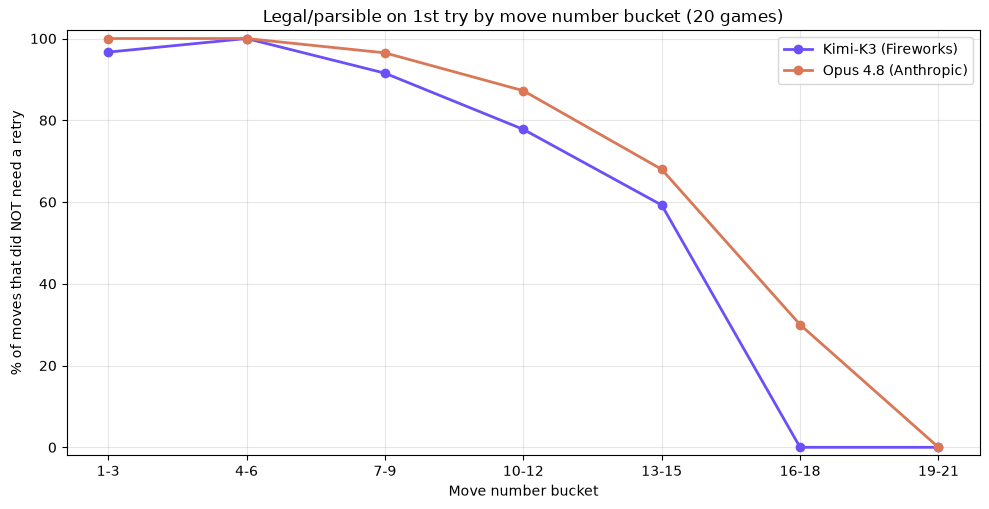

Saved llm_chess_no_retry_rate_by_bucket.png


In [ ]:
import matplotlib.pyplot as plt
import math

# --- Retry Rate By Move Number (summary line chart) ---
# Aggregate retry events by (provider, move_number) across all games.
# Only count moves the model actually attempted (legal moves + forfeit moves).
by_prov: dict[str, dict[int, list[bool]]] = {p: {} for p in providers}
for g in games:
    for e in g["log"]:
        prov = e["provider"]
        mn = e.get("move_number")
        if mn is None:
            continue  # older runs without the field
        by_prov[prov].setdefault(mn, []).append(bool(e.get("retried", False)))

# Bucket move numbers 1-3, 4-6, 7-9, etc.
def move_bucket(mn):
    # Bucket indices: 1-3 => 1, 4-6 => 4, 7-9 => 7, etc.
    if mn is None:
        return None
    return 1 + 3 * ((mn - 1) // 3)

# Per-provider bucket aggregation: bucket => list of True/False for "retried"
by_prov_bucket: dict[str, dict[int, list[bool]]] = {p: {} for p in providers}
for prov, mn_map in by_prov.items():
    for mn, retry_list in mn_map.items():
        bucket = move_bucket(mn)
        if bucket is not None:
            by_prov_bucket[prov].setdefault(bucket, []).extend(retry_list)

# Build per-model sorted x/y arrays: x = move bucket, y = % of moves that did NOT need a retry in that bucket.
series = {}
all_buckets = set()
for prov, bucket_map in by_prov_bucket.items():
    xs = sorted(bucket_map)
    ys = [
        100.0 * (1.0 - (sum(bucket_map[b]) / len(bucket_map[b])))
        for b in xs
    ]
    series[prov] = (xs, ys)
    all_buckets.update(xs)

# For better x-tick bucket labeling, generate range labels for each bucket boundary present
def bucket_label(bucket_start):
    return f"{bucket_start}-{bucket_start + 2}"

all_buckets_sorted = sorted(all_buckets)
xticks = all_buckets_sorted
xtick_labels = [bucket_label(b) for b in xticks]

fig, ax = plt.subplots(figsize=(10, 5.2))
colors = {PLAYER_A[0]: "#6C4FF6", PLAYER_B[0]: "#D97757"}
for prov, (xs, ys) in series.items():
    ax.plot(xs, ys, marker="o", linewidth=2, color=colors.get(prov, None), label=providers[prov])
ax.set_xlabel("Move number bucket")
ax.set_ylabel("% of moves that did NOT need a retry")
ax.set_title(f"Legal/parsible on 1st try by move number bucket ({len(games)} games)")
ax.set_ylim(-2, 102)
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("llm_chess_no_retry_rate_by_bucket.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved llm_chess_no_retry_rate_by_bucket.png")

## 7. Inspect a single game

Move table and per-move raw output for `INSPECT_GAME` (0-indexed). Handy for seeing exactly where a model went off the rails.

In [ ]:
g = games[INSPECT_GAME]
print(f"Game {g['game'] + 1}: {g['white']['name']} (W) vs {g['black']['name']} (B) "
      f"| {g['plies']} plies | {g['outcome']} | winner: {g['winner_name'] or 'draw'}")
print()


def move_table(log: list[dict]) -> str:
    rows = []
    for i in range(0, len(log), 2):
        num = i // 2 + 1
        w = log[i]
        white = w["san"] or "(forfeit)"
        black = ""
        if i + 1 < len(log):
            b = log[i + 1]
            black = b["san"] or ("(forfeit)" if b.get("forfeit") else "")
        rows.append(f"{num:>2}. {white:<8} {black:<8}")
    return "\n".join(rows)

print(move_table(g["log"]))
print()
print("Per-move detail:")
for e in g["log"]:
    name = g["white"]["name"] if e["side"] == "white" else g["black"]["name"]
    san = e["san"] or "(illegal)"
    raw = (e["raw"] or "").replace("\n", " ").strip()
    if len(raw) > 100:
        raw = raw[:97] + "..."
    flag = "  [forfeit]" if e.get("forfeit") else ""
    lat = e.get("latency")
    lat_s = f"{lat:.1f}s" if lat is not None else "-"
    print(f"{e['ply']:>3}. {name:<22} -> {san:<8} ({lat_s}){flag}  | {raw}")

Game 1: GLM-5.2 (Fireworks) (W) vs Opus 4.8 (Anthropic) (B) | 28 plies | forfeit | winner: GLM-5.2 (Fireworks)

 1. e4       c5      
 2. Nf3      d6      
 3. d4       cxd4    
 4. Nxd4     Nf6     
 5. Nc3      a6      
 6. Be3      e5      
 7. Nb3      Be6     
 8. f3       Be7     
 9. Qd2      O-O     
10. O-O-O    Nbd7    
11. g4       b5      
12. g5       b4      
13. Nd5      Bxd5    
14. gxf6     (forfeit)

Per-move detail:
  1. GLM-5.2 (Fireworks)    -> e4       (7.2s)  | Looking at the starting position, I need to choose a move that fights for central control and ope...
  2. Opus 4.8 (Anthropic)   -> c5       (2.1s)  | I'll respond to 1.e4 with the Sicilian Defense, a sharp and combative choice that fights for the ...
  3. GLM-5.2 (Fireworks)    -> Nf3      (3.8s)  | The opponent has chosen the Sicilian Defense, the most popular and aggressive response to 1.e4. T...
  4. Opus 4.8 (Anthropic)   -> d6       (1.8s)  | [d6]
  5. GLM-5.2 (Fireworks)    -> d4       (1.9s)  | d4


## 8. Notes

- Each model only sees its own conversation thread — its own moves are `assistant` turns, the opponent's moves arrive as `user` turns. That is the "each LLM thinks it is the user / the assistant is the other LLM" framing.
- **Incremental save / resume.** Each finished game is appended to `SAVE_PATH` (default `llm_chess_games.jsonl`) as one JSONL line and `fsync`ed, so a crash mid-match keeps all completed games. Set `RESUME = True` to continue a previous run — already-saved game indices are skipped. If the kernel dies, run the "Recover from a partial run" cell to reload `games` from the save and recompute stats/charts without re-playing. For a fresh 100-game run from scratch, delete (or rename) the save file first, or set `RESUME = False` and append mode will keep adding to it.
- Colors swap every game, so over an even `N_GAMES` each model plays White exactly half the time. Win stats are split by White/Black to expose any first-move advantage.
- Illegal-move tracking counts **every** bad attempt across retries (not just the final forfeiting one). `unparseable` = the model rambled and no SAN was found; `illegal_san` = a SAN was found but it wasn't legal on the live board.
- Latency is wall time per model call (including retries), so a model that rambles and gets retried shows up as more samples and more total thinking time.
- Reasoning effort is set to `high` on both models: GLM-5.2 uses `reasoning_effort="high"` (the lower of its two real tiers, `high`/`max`; unset defaults to `max`), and Opus 4.8 uses `output_config={"effort": "high"}` with `thinking={"type": "adaptive"}` (Opus 4.8 rejects manual `thinking: {type: "enabled", budget_tokens}` — adaptive is the only supported thinking mode). Drop GLM to `reasoning_effort="none"` (thinking off) or Opus to `effort: "low"` for faster, weaker play.
- Swap models by editing `PLAYER_A`/`PLAYER_B` and the `_MODEL` ids. The two call paths are provider-specific because Anthropic's `system` is a top-level arg and Opus 4.8 rejects `temperature`.